# Ensemble Learning(앙상블 학습 방법)

*   앙상블(ensemble): ML에서 사용되는 일련의 모델(알고리즘)들.
    *   서로 다른 모델(알고리즘) 여러개를 훈련시키는 방법.
    *   한 가지 모델(알고리즘)을 서로 다른 훈련 셋으로 훈련시키는 방법.

*   앙상블 학습방법: 앙상블을 사용한 학습 방법
    *   투표(voting):  여러 개의 모델들을 같은 훈련 셋으로 학습시킨 후, 각각의 모델들의 예측값들을 투표(최빈값, 평균) 방식으로 결정하는 방법.
    *   **Bagging(Bootstrap Aggregating)**: **중복을 허용**해서 샘플링한 훈련 셋의 부분집합들로 여러개의 모델들을 학습시킨 후 예측(최빈값, 평균)하는 방법.
    *   Pasting: 중복을 허용하지 않고 샘플링한 훈련 셋의 부분집합들로 여러개의 모델들을 학습시킨 후 예측하는 방법.
    *   **Boosting**: 약한 학습기(weak learner)를 **순차적**으로 연결해서 강한 학습기(strong learner)를 만드는 앙상블 학습 방법.
        *   AdaBoost(Adaptive Boosting): 과소적합됐던 훈련 샘플들의 가중치를 높여서 그 다음 학습에서 사용하는 boosting 방법.
        *   Gradient Boosting: 잔여 오차(residual errors)들을 다음 훈련에서 학습시키는 boosting 방법.
*   **Random Forest**: Bagging을 이용한 Decision Tree들의 앙상블 학습 방법.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC  # SVM(Support Vector Machine) 알고리즘을 사용한 분류기
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV

# 데이터셋 준비

2개의 특성(x1, x2)과 2개의 클래스(0, 1)를 갖는 가상의 데이터셋 만들고 사용.

In [2]:
# x: 특성 배열, y: 타겟 배열
x, y = datasets.make_moons(n_samples=500, random_state=42, noise=0.1)

In [3]:
x.shape, y.shape

((500, 2), (500,))

In [4]:
np.unique(y, return_counts=True)

(array([0, 1]), array([250, 250]))

In [7]:
x[:6]

array([[ 0.83067643, -0.40993581],
       [ 0.79835529,  0.83761218],
       [ 1.05046846, -0.48516193],
       [-0.25814276,  0.98000844],
       [ 0.3306816 ,  1.14763307],
       [ 1.26625226, -0.49698361]])

In [8]:
y[:6]

array([1, 0, 1, 0, 0, 1])

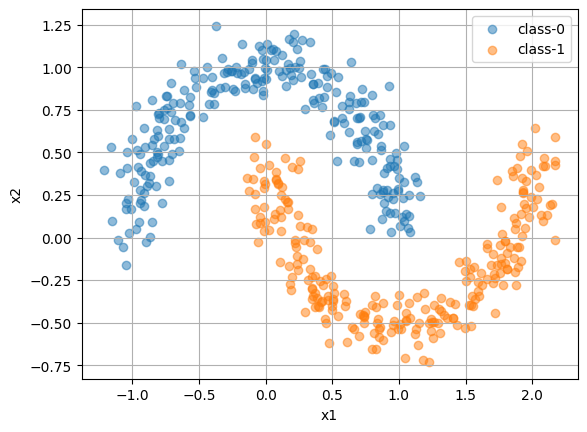

In [11]:
plt.scatter(x=x[y == 0, 0], y=x[y == 0, 1], label='class-0', alpha=0.5)
plt.scatter(x=x[y == 1, 0], y=x[y == 1, 1], label='class-1', alpha=0.5)

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid()
plt.show()